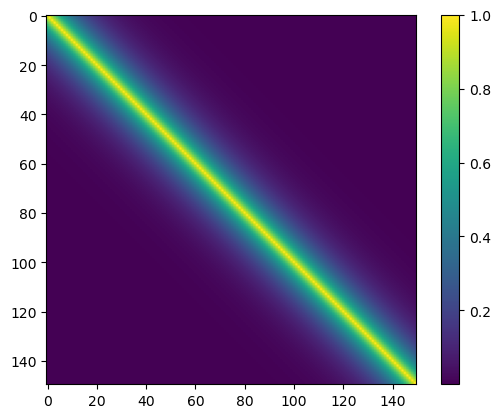

In [10]:
import numpy as np
from scipy.linalg import cholesky, solve_triangular
import matplotlib.pyplot as plt

def exponential_covariance(length, scale=10):
    '''
    Generate the covariance matrix for exponential decay noise model
    '''
    x = np.arange(length)
    cov_matrix = np.exp(-np.abs(x[:, None] - x[None, :]) / scale)
    return cov_matrix
    
def calc_InversionDeterminant_cd(cov_d):
    '''
    Compute the inverse of matrix N-by-N cov_d, where N is the number of samples
    '''
    ns,nc,nt,_ = cov_d.shape
    cov_inv = np.zeros((ns,nc,nt,nt))
    log_cov_det = np.zeros((ns,nc))
    # Cholesky decomposition to obtain lower matrix
    for ist in range(ns):
        for ic in range(nc):
            cov = cov_d[ist,ic] 
            covL = cholesky(cov, lower=True)
            #log of sqrt determinant
            factor = np.sum(np.log(np.abs(np.diag(covL))))
            covL /= np.exp(factor / nt)
            
            # Invert combined matrix
            covL_inv = solve_triangular(covL, np.eye(nt), lower=True)
            cov_inv[ist,ic] = np.matmul(covL_inv.T, covL_inv)
            log_cov_det[ist,ic] = factor
    return cov_inv, log_cov_det

ns = 8
nc = 3
nt = 150

cov_matrix1 = exponential_covariance(length=nt, scale=10)
cov_matrix2 = exponential_covariance(length=nt, scale=2)
# cov_d = np.zeros((ns,nc,nt,nt))
# for s in range(ns):
#     for c in range(nc):
#         cov_d[s,c] = cov_matrix

# cov_inv, log_cov_det = calc_InversionDeterminant_cd(cov_d)

# plt.imshow(cov_matrix1-cov_matrix2)
plt.imshow(cov_matrix1)
plt.colorbar()
plt.show()


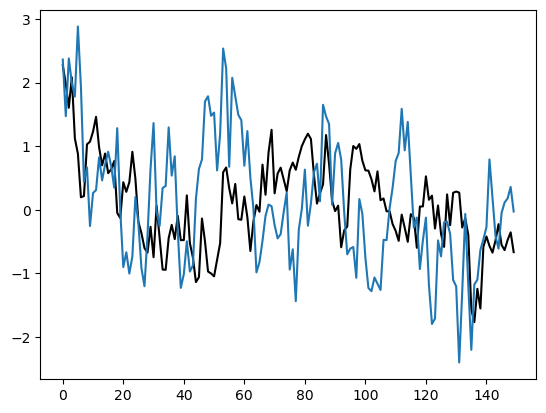

In [6]:
cov_matrix1 = exponential_covariance(length=nt, scale=10)
cov_matrix2 = exponential_covariance(length=nt, scale=4)
mean = np.zeros(nt)
noise1 = np.random.multivariate_normal(mean, cov_matrix1)
noise2 = np.random.multivariate_normal(mean, cov_matrix2)
plt.plot(noise1,'k')
plt.plot(noise2)

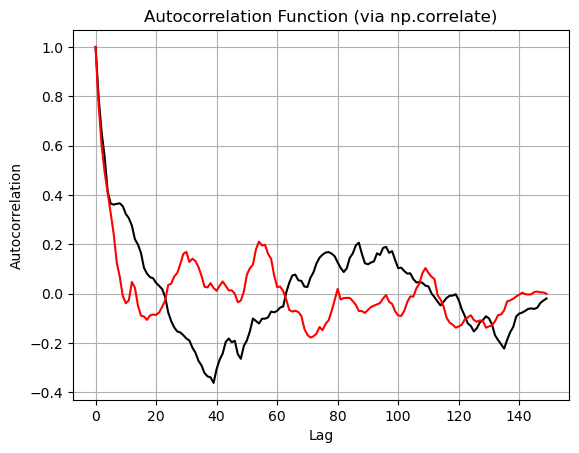

In [7]:
result = np.correlate(noise1, noise1, mode='full')
acf_full1 = result[result.size // 2:] / result[result.size // 2]

result = np.correlate(noise2, noise2, mode='full')
acf_full2 = result[result.size // 2:] / result[result.size // 2]

plt.plot(acf_full1, 'k')
plt.plot(acf_full2, 'r')
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.title("Autocorrelation Function (via np.correlate)")
plt.grid()
plt.show()

In [16]:
from pyrocko.moment_tensor import MomentTensor

# tmp = np.loadtxt('mt_input.txt')
# tmp =  np.array([-8.88783183e+15,  4.66977228e+16, -3.78098910e+16,  \
#                    3.71126807e+15, 2.09101333e+16,  1.47054371e+16])
tmp = np.array([-0.089, 0.467, -0.378,  \
                0.037,  0.209, 0.147]) *1.0e17
# tmp = np.array([2.760, -1.661, -1.099, 0.707, 1.048, 0.634])*3.0e16
mt = MomentTensor.from_values(tmp)
print(mt)
mt_decom = mt.standard_decomposition()
c_ISO, c_DC, c_CLVD = 100*mt_decom[0][1], 100*mt_decom[1][1], 100*mt_decom[2][1]
print(c_ISO, c_DC, c_CLVD )
print(mt.moment_magnitude())
print(mt.both_strike_dip_rake())

Scalar Moment [Nm]: M0 = 5.01105e+16 (Mw = 5.1)
Moment Tensor [Nm]: Mnn = -0.089,  Mee =  0.467, Mdd = -0.378,
                    Mne =  0.037,  Mnd =  0.209, Med =  0.147    [ x 1e+17 ]
Fault plane 1 [deg]: strike = 332, dip =  60, slip-rake = -118
Fault plane 2 [deg]: strike = 200, dip =  40, slip-rake =  -50

0.0 99.95872330062068 0.04127669937931899
5.099952363331974
[(332.4038103374828, 60.49819251592518, -118.35091400464408), (200.01907550675284, 40.008610090219186, -49.99431040742253)]


In [14]:
import sys
sys.path.insert(0, '/Users/hujy/Documents/Research/BayMTI/src/')
from utils.math import to_lune, Tashiro2MT6,ned2rtp
from mtuq.util.math import to_mij, to_rho, to_delta_gamma, to_Mw


rho,v,w,kappa,sigma,h = to_lune(tmp)
delta, gamma = to_delta_gamma(v, w)

print(delta, gamma)
print('Mw ', to_Mw(rho))

-1.4003676929234444e-08 1.3498248010972279e-09
Mw  5.066666666522102
